In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [6]:
model.invoke("what is the color of the water").content #human message

'The color of water is a fascinating topic because it\'s not as simple as saying "water is blue." Here\'s a breakdown of why and what factors influence its color:\n\n**Pure Water is Actually Colorless, but Appears Blue:**\n\n* **Absorption and Scattering:** This is the primary reason why large bodies of water, like oceans and deep lakes, appear blue. Water molecules absorb light in the red and yellow portions of the spectrum more strongly than they absorb blue light. The blue light is then scattered in all directions, and our eyes perceive this scattered blue light as the color of the water. The deeper the water, the more pronounced this effect becomes.\n\n**Factors that Influence Water Color:**\n\n* **Depth:** As mentioned, deeper water appears bluer due to increased absorption and scattering of light. Shallow water might appear clearer or take on the color of the bottom.\n* **Sediment and Suspended Particles:** This is a major factor.\n    * **Muddy or Silty Water:** If water contain

In [10]:
from langchain_core.messages import SystemMessage, HumanMessage

model.invoke([HumanMessage(content = "Why is the sky blue ?")]).content


"The sky is blue because of a phenomenon called **Rayleigh scattering**. It's all about how sunlight interacts with the Earth's atmosphere.\n\nHere's a breakdown:\n\n1.  **Sunlight is White Light:** Sunlight appears white to us, but it's actually a spectrum of all the colors of the rainbow (red, orange, yellow, green, blue, indigo, violet). Each color has a different wavelength.\n\n2.  **Earth's Atmosphere:** Our atmosphere is made up of tiny molecules, primarily nitrogen (about 78%) and oxygen (about 21%), along with smaller amounts of other gases and particles.\n\n3.  **Scattering of Light:** When sunlight enters the atmosphere, it bumps into these gas molecules and other particles. This causes the light to scatter, meaning it gets redirected in all directions.\n\n4.  **Wavelength Matters:** Rayleigh scattering states that shorter wavelengths of light are scattered more effectively than longer wavelengths.\n    *   **Blue and violet light have shorter wavelengths.**\n    *   **Red an

In [ ]:
from typing import TypedDict, List, Annotated
from operator import add

class graph_schema(TypedDict):
    message_manual: List
    #using reduced in lang graph
    messages_auto: Annotated[List,add]

In [ ]:
from langchain_core.messages import AIMessage

def NODE1(state:graph_schema) -> graph_schema:

    message = state['message_manual']
    message_manual_ai = model.invoke(message).content
    state['message_manual'].append(AIMessage(content = message_manual_ai))

    message_auto = state['message_auto']
    response_auto = model.invoke(message_auto).content
    response_auto_ai = AIMessage(content = response_auto)

    state['message_auto'] = response_auto_ai

    return state

In [80]:
def NODE2(state:graph_schema) -> graph_schema:
    message = state['message_manual']
    message__auto = model.invoke([HumanMessage(content = message[-1].content)]).content
    state['message_manual'].append(AIMessage(content = message__auto))

    message_auto = state['message_auto']
    response_auto = model.invoke([HumanMessage(content = message__auto[-1].content)]).content
    response_auto_ai = AIMessage(response_auto)
    state['message_auto'] = response_auto_ai

    return state

In [81]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("NODE1", NODE1)
graph.add_node("NODE2", NODE2)

graph.add_edge(START,"NODE1")
graph.add_edge("NODE1","NODE2")
graph.add_edge("NODE2",END)

In [82]:
message_graph = graph.compile()

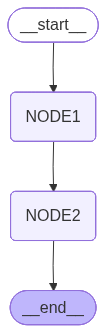

In [83]:
from IPython.display import Image,display

Image(message_graph.get_graph().draw_mermaid_png())

In [87]:
message_graph.invoke(
    {'message_manual':[HumanMessage(content ="hello how are you ?")],
     'message_auto':[HumanMessage(content = "do you have job or something?")]}

)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 44.717427311s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM